In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [110]:
pd.set_option('display.max_columns', None)

In [111]:
df = pd.read_csv('./Data/gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [112]:
df.head()

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,emaar palm gardens,sector 83,1.8 Crore,9473.0,Super Built up area 1900(176.52 sq.m.),3,3,3+,9.0,South,1 to 5 Year Old,NaN,1900.0,NaN,NaN,0,0,0,0,0,0,55
1,flat,breez global hill view,sohna road,29.99 Lac,5403.0,Super Built up area 655(60.85 sq.m.)Carpet are...,2,2,2,6.0,North-East,0 to 1 Year Old,NaN,655.0,NaN,555.0,0,0,0,0,0,0,109
2,flat,ambience creacions,sector 22,4.78 Crore,15469.0,Super Built up area 3090(287.07 sq.m.)Built Up...,3,4,3,7.0,West,1 to 5 Year Old,NaN,3090.0,2500.0,2250.0,0,1,0,0,1,2,111
3,flat,aipl zen residences,sector 70a,1.25 Crore,9904.0,Carpet area: 1262 (117.24 sq.m.),2,2,3,19.0,NaN,undefined,NaN,NaN,NaN,1262.0,0,0,0,0,0,0,0
4,flat,sare homes,sector 92,1.18 Crore,5207.0,Carpet area: 2266 (210.52 sq.m.),4,4,3,8.0,North,1 to 5 Year Old,NaN,NaN,NaN,2266.0,0,1,0,0,0,0,108


In [113]:
df['super_built_up_area']

0       1900.0
1        655.0
2       3090.0
3          NaN
4          NaN
         ...  
3811       NaN
3812       NaN
3813    1245.0
3814    1621.0
3815    1740.0
Name: super_built_up_area, Length: 3689, dtype: float64

In [114]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'area', 'super_built_up_area', 'built_up_area',
       'carpet_area', 'study room', 'servant room', 'store room', 'pooja room',
       'others', 'furnishing_type', 'luxury_score'],
      dtype='object')

In [115]:
def convert_to_crore(x):
    x = str(x).lower().strip()
    
    if 'crore' in x:
        value = float(x.replace('crore', '').strip())
    
    elif 'lac' in x:
        value = float(x.replace('lac', '').strip()) * 0.01
    
    else:
        return None
    
    return round(value, 2)  # keep only 2 decimal places


df['price'] = df['price'].apply(convert_to_crore)

C:\Users\kael7\AppData\Local\Temp\ipykernel_44368\2797181776.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

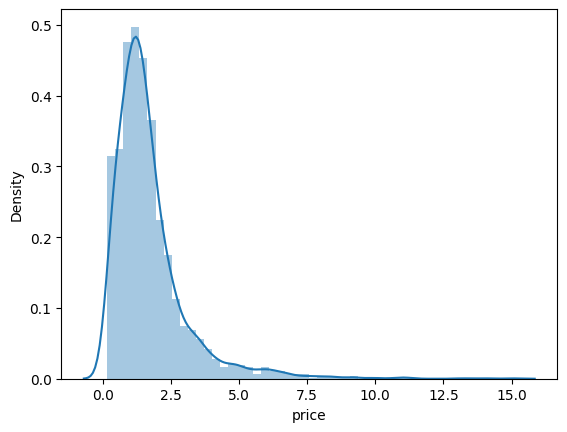

In [116]:
# outliers on the basis of price column
sns.distplot(df['price'])

<Axes: xlabel='price'>

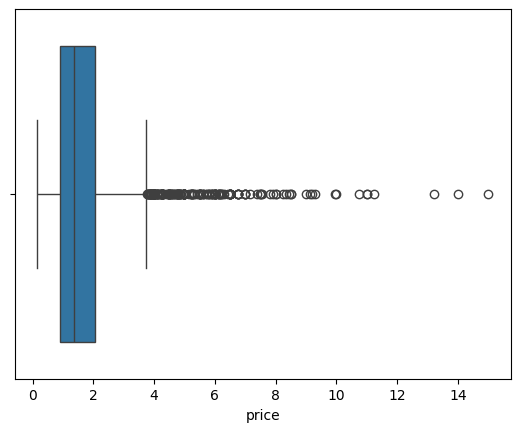

In [117]:
sns.boxplot(x=df['price'])

In [118]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(188,
 count    188.000000
 mean       5.651277
 std        1.928272
 min        3.780000
 25%        4.250000
 50%        5.000000
 75%        6.262500
 max       15.000000
 Name: price, dtype: float64)

In [119]:
outliers.sort_values('price',ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
275,flat,central park resorts,sector 48,15.00,22388.0,Carpet area: 6700 (622.45 sq.m.),5,6,3+,17.0,NaN,1 to 5 Year Old,NaN,NaN,NaN,6700.0,1,1,0,1,0,2,45
366,flat,ambience caitriona,sector 24,14.00,200000.0,Built Up area: 700 (65.03 sq.m.),4,5,3,3.0,East,undefined,NaN,NaN,700.0,NaN,0,0,0,0,0,0,0
3504,flat,m3m golfestate,sector 65,13.20,12000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,5 to 10 Year Old,NaN,NaN,NaN,11000.0,0,1,0,0,0,0,60
3290,flat,central park resorts,sector 48,11.25,28266.0,Carpet area: 3980 (369.75 sq.m.),4,5,3+,2.0,North-West,1 to 5 Year Old,NaN,NaN,NaN,3980.0,0,1,0,1,0,0,45
1167,flat,dlf the crest,sector 54,11.00,35222.0,Super Built up area 3123(290.14 sq.m.),4,6,3,7.0,NaN,1 to 5 Year Old,NaN,3123.0,NaN,NaN,0,1,0,0,0,2,125
3300,flat,dlf the crest,sector 54,11.00,35483.0,Carpet area: 3100 (288 sq.m.),4,5,3+,7.0,North-East,1 to 5 Year Old,NaN,NaN,NaN,3100.0,1,1,0,1,0,0,49
2542,flat,pioneer araya,sector 62,10.75,19500.0,Super Built up area 5514(512.27 sq.m.),5,7,3,10.0,North-East,1 to 5 Year Old,NaN,5514.0,NaN,NaN,0,1,0,0,0,1,153
1779,flat,dlf the belaire,sector 54,10.00,24557.0,Super Built up area 4072(378.3 sq.m.)Built Up ...,4,5,3+,17.0,North,5 to 10 Year Old,NaN,4072.0,3000.0,2800.0,0,1,0,0,0,2,167
2698,flat,pioneer araya,sector 62,9.95,20995.0,Super Built up area 4739(440.27 sq.m.)Carpet a...,4,6,3,12.0,South-East,1 to 5 Year Old,NaN,4739.0,NaN,3219.0,0,1,0,1,0,1,138
1880,flat,central park resorts,sector 48,9.30,24926.0,Super Built up area 3931(365.2 sq.m.)Built Up ...,4,4,3+,10.0,North-East,5 to 10 Year Old,NaN,3931.0,3831.0,3731.0,1,1,1,1,0,1,67


In [120]:
# on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

### Price_per_sqft

C:\Users\kael7\AppData\Local\Temp\ipykernel_44368\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

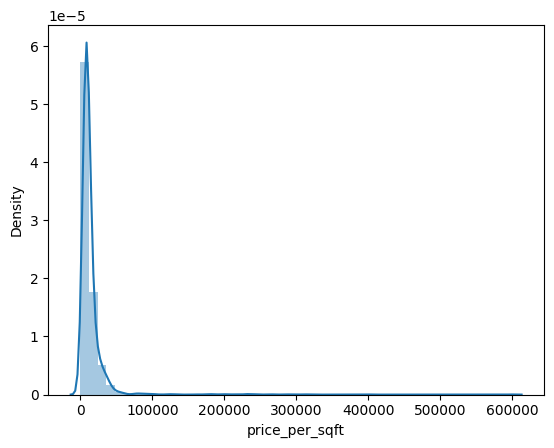

In [121]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

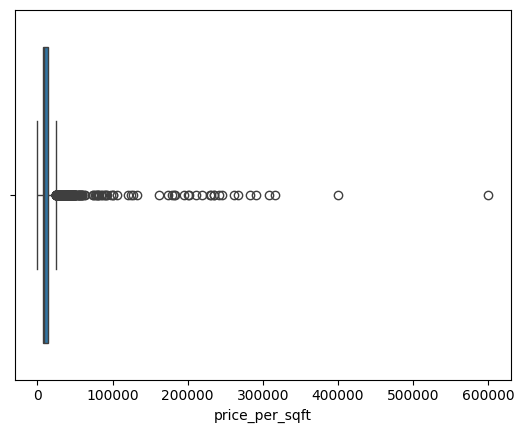

In [122]:
sns.boxplot(x=df['price_per_sqft'])

In [123]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(354,
 count       354.000000
 mean      52592.612994
 std       61150.458507
 min       24489.000000
 25%       28208.250000
 50%       33368.500000
 75%       41982.250000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [124]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\kael7\AppData\Local\Temp\ipykernel_44368\205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [125]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

C:\Users\kael7\AppData\Local\Temp\ipykernel_44368\3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [126]:
outliers_sqft['price_per_sqft'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: price_per_sqft, dtype: float64

In [127]:
df.update(outliers_sqft)

C:\Users\kael7\AppData\Local\Temp\ipykernel_44368\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

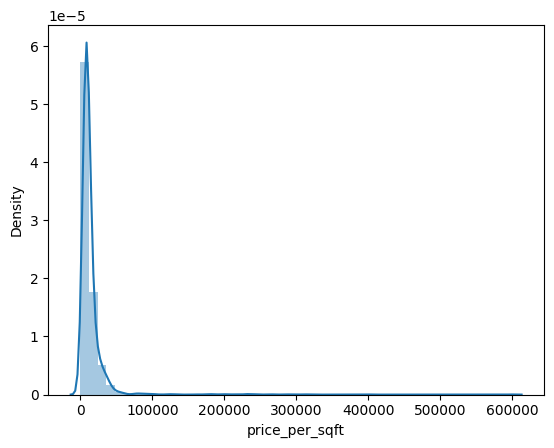

In [128]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

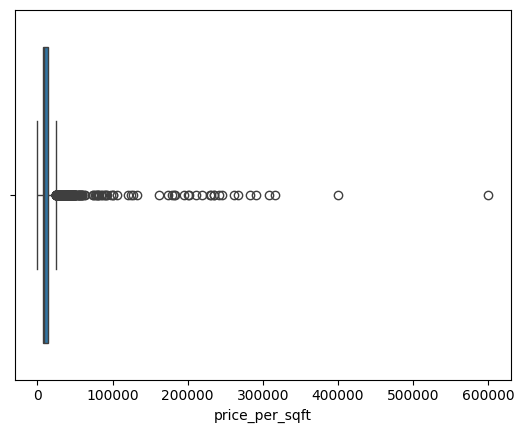

In [129]:
sns.boxplot(x=df['price_per_sqft'])

In [130]:
df[df['price_per_sqft']>50000]

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
74,house,"bhim nagar, sector 6",sector 6,NaN,126865.0,Plot area 67(6.22 sq.m.),5,2,2,1.0,NaN,10+ Year Old,603.0,NaN,67.0,NaN,0,0,0,1,0,0,29
206,house,NaN,sector 3,NaN,80357.0,Built Up area: 112 (10.41 sq.m.),3,3,0,2.0,NaN,undefined,1008.0,NaN,112.0,NaN,0,0,0,0,0,0,0
221,house,unitech deerwood chase,sector 50,NaN,235376.0,Plot area 359(33.35 sq.m.),3,3,2,2.0,North-East,10+ Year Old,3231.0,NaN,359.0,NaN,1,1,0,0,0,1,102
225,house,huda plot sector 38,sector 38,NaN,245398.0,Plot area 163(15.14 sq.m.)Built Up area: 145 s...,13,13,3+,5.0,North-West,1 to 5 Year Old,1575.0,NaN,145.0,NaN,0,0,0,0,0,2,7
305,house,NaN,sector 105,NaN,98214.0,Built Up area: 56 (5.2 sq.m.),4,4,0,2.0,NaN,undefined,504.0,NaN,56.0,NaN,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3399,house,NaN,sector 5,NaN,57692.0,Built Up area: 130 (12.08 sq.m.),2,2,0,1.0,NaN,undefined,1170.0,NaN,130.0,NaN,0,0,0,0,0,0,0
3480,house,NaN,sector 4,NaN,88157.0,Plot area 76(7.06 sq.m.),3,3,2,2.0,South,1 to 5 Year Old,684.0,NaN,76.0,NaN,0,0,0,0,1,0,7
3516,house,NaN,sector 24,NaN,229885.0,Carpet area: 435 (40.41 sq.m.),8,10,3+,1.0,West,undefined,3915.0,NaN,NaN,435.0,0,0,0,0,0,0,0
3529,house,NaN,sector 26,NaN,51864.0,Plot area 316(264.22 sq.m.),16,20,3+,4.0,East,0 to 1 Year Old,2844.0,NaN,316.0,NaN,1,1,1,1,0,1,153


In [131]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

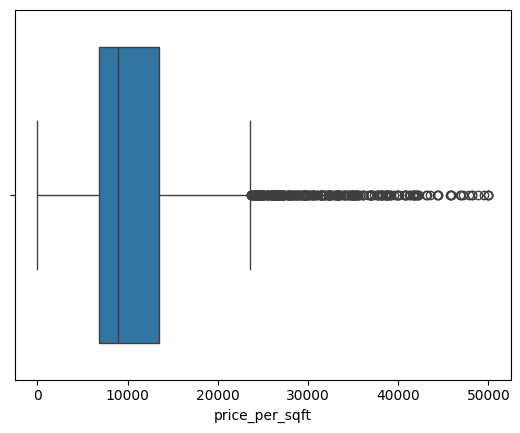

In [132]:
sns.boxplot(x=df['price_per_sqft'])

### Area

C:\Users\kael7\AppData\Local\Temp\ipykernel_44368\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

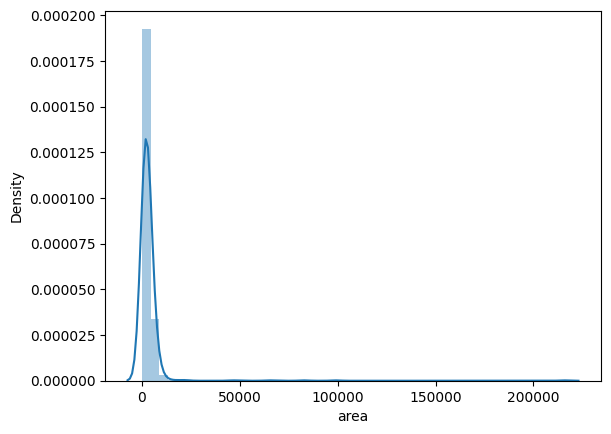

In [133]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

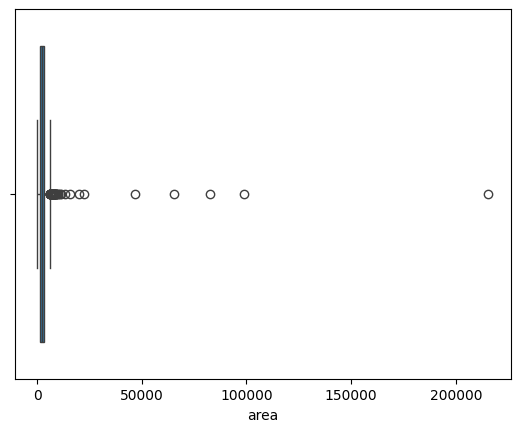

In [134]:
sns.boxplot(x=df['area'])

In [135]:
df['area'].describe()

count       783.000000
mean       3303.066411
std        9463.562658
min         145.000000
25%        1350.000000
50%        2250.000000
75%        3240.000000
max      215517.000000
Name: area, dtype: float64

In [136]:
df[df['area'] > 100000]

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
160,house,NaN,sector 50,NaN,232.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,0 to 1 Year Old,215517.0,NaN,2.0,NaN,1,1,0,1,1,1,0


In [137]:
df = df[df['area'] < 100000]

C:\Users\kael7\AppData\Local\Temp\ipykernel_44368\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

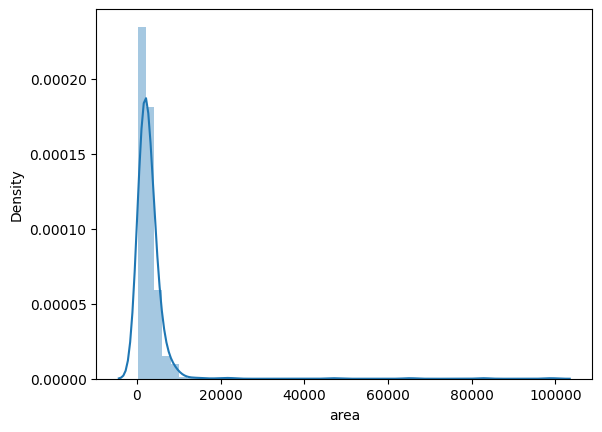

In [138]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

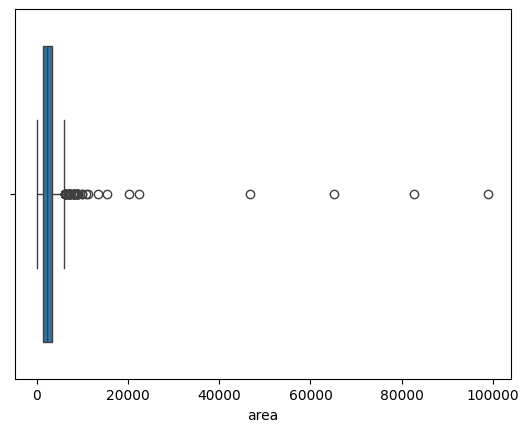

In [139]:
sns.boxplot(x=df['area'])

In [140]:
df[df['area'] > 10000].sort_values('area',ascending=False)

# 818, 1796, 1123, 2, 2356, 115, 3649, 2503, 1471

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3190,house,NaN,sector 26,NaN,1859.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,1 to 5 Year Old,98978.0,NaN,NaN,11000.0,0,1,1,1,0,1,60
453,house,ganpati heights apartment,sector 13,NaN,151.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,10+ Year Old,82781.0,NaN,115.0,NaN,0,0,0,0,1,0,7
2690,house,dlf city plot phase 4,sector 28,NaN,1992.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,undefined,65261.0,NaN,NaN,7250.0,0,0,0,0,0,0,0
2800,house,NaN,sector 25,NaN,1560.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,1 to 5 Year Old,46795.0,NaN,5800.0,5200.0,0,1,1,0,0,1,109
2744,house,NaN,sector 57,NaN,2778.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,0 to 1 Year Old,22498.0,NaN,2660.0,2500.0,0,1,0,0,0,1,61
415,house,NaN,sector 43,NaN,2716.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,5 to 10 Year Old,20250.0,NaN,2850.0,2250.0,1,1,0,1,1,1,123
1109,house,unitech aspen greens,sector 50,NaN,4490.0,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,2.0,North-East,5 to 10 Year Old,15479.0,NaN,2160.0,1720.0,0,1,0,0,0,0,160
2521,house,NaN,sector 4,NaN,630.0,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,1 to 5 Year Old,13492.0,NaN,1500.0,NaN,0,0,0,0,1,0,0
2169,house,NaN,sector 43,NaN,24366.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,1 to 5 Year Old,11286.0,NaN,1254.0,NaN,1,1,0,1,1,1,42
2483,house,NaN,sohna road,NaN,5093.0,Plot area 1200(1003.35 sq.m.)Built Up area: 35...,3,3,3+,2.0,West,5 to 10 Year Old,10799.0,NaN,3500.0,NaN,1,1,0,1,1,0,49


In [141]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3190,house,NaN,sector 26,NaN,1859.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,1 to 5 Year Old,98978.0,NaN,NaN,11000.0,0,1,1,1,0,1,60
453,house,ganpati heights apartment,sector 13,NaN,151.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,10+ Year Old,82781.0,NaN,115.0,NaN,0,0,0,0,1,0,7
2690,house,dlf city plot phase 4,sector 28,NaN,1992.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,undefined,65261.0,NaN,NaN,7250.0,0,0,0,0,0,0,0
2800,house,NaN,sector 25,NaN,1560.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,1 to 5 Year Old,46795.0,NaN,5800.0,5200.0,0,1,1,0,0,1,109
2744,house,NaN,sector 57,NaN,2778.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,0 to 1 Year Old,22498.0,NaN,2660.0,2500.0,0,1,0,0,0,1,61
415,house,NaN,sector 43,NaN,2716.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,5 to 10 Year Old,20250.0,NaN,2850.0,2250.0,1,1,0,1,1,1,123
1109,house,unitech aspen greens,sector 50,NaN,4490.0,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,2.0,North-East,5 to 10 Year Old,15479.0,NaN,2160.0,1720.0,0,1,0,0,0,0,160
2521,house,NaN,sector 4,NaN,630.0,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,1 to 5 Year Old,13492.0,NaN,1500.0,NaN,0,0,0,0,1,0,0
2169,house,NaN,sector 43,NaN,24366.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,1 to 5 Year Old,11286.0,NaN,1254.0,NaN,1,1,0,1,1,1,42
2483,house,NaN,sohna road,NaN,5093.0,Plot area 1200(1003.35 sq.m.)Built Up area: 35...,3,3,3+,2.0,West,5 to 10 Year Old,10799.0,NaN,3500.0,NaN,1,1,0,1,1,0,49


In [142]:
df.loc[48,'area'] = 115*9
df.loc[300,'area'] = 7250
df.loc[2666,'area'] = 5800
df.loc[1358,'area'] = 2660
df.loc[3195,'area'] = 2850
df.loc[2131,'area'] = 1812
df.loc[3088,'area'] = 2160
df.loc[3444,'area'] = 1175

C:\Users\kael7\AppData\Local\Temp\ipykernel_44368\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

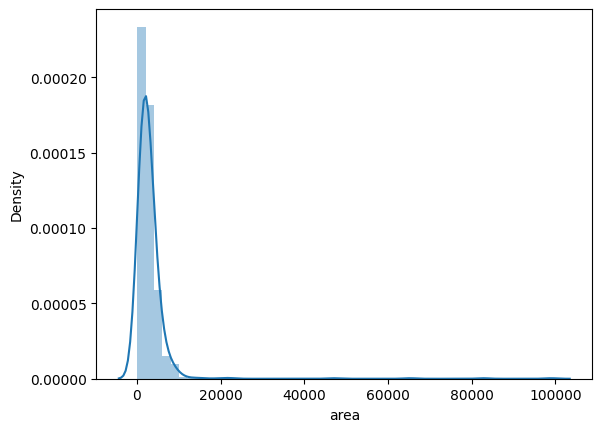

In [143]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

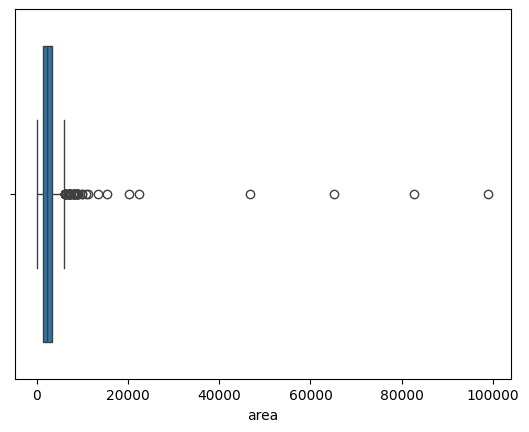

In [144]:
sns.boxplot(x=df['area'])

In [145]:
df['area'].describe()

count      788.000000
mean      3038.913706
std       5632.149908
min        145.000000
25%       1350.000000
50%       2250.000000
75%       3240.000000
max      98978.000000
Name: area, dtype: float64

### Bedroom

C:\Users\kael7\AppData\Local\Temp\ipykernel_44368\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

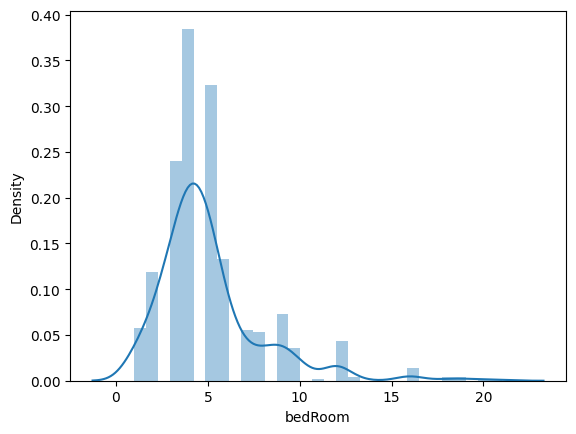

In [146]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

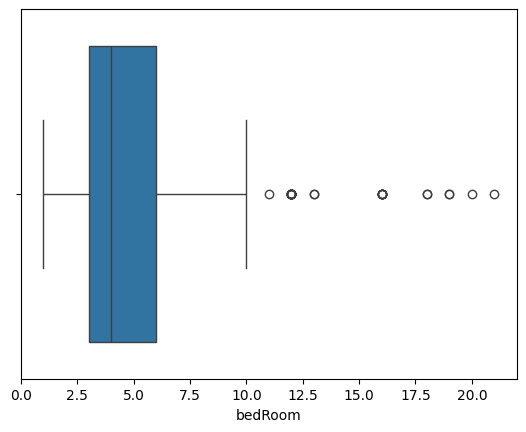

In [147]:
sns.boxplot(x=df['bedRoom'])

In [148]:
df['bedRoom'].describe()

count    782.000000
mean       5.061381
std        2.872238
min        1.000000
25%        3.000000
50%        4.000000
75%        6.000000
max       21.000000
Name: bedRoom, dtype: float64

In [149]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
704,house,NaN,sector 54,NaN,43066.0,Plot area 129(107.86 sq.m.),21.0,21.0,3+,5.0,North,1 to 5 Year Old,1161.0,NaN,129.0,NaN,0.0,1.0,0.0,0.0,0.0,2.0,49.0
61,house,NaN,sector 43,NaN,39062.0,Plot area 128(107.02 sq.m.),20.0,20.0,3+,4.0,East,1 to 5 Year Old,1152.0,NaN,128.0,NaN,0.0,1.0,0.0,0.0,0.0,2.0,22.0
1412,house,NaN,sector 17a,NaN,5160.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19.0,17.0,3+,5.0,North-West,1 to 5 Year Old,7500.0,NaN,7500.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,68.0
2488,house,NaN,sector 17a,NaN,24214.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19.0,17.0,3,4.0,North-West,1 to 5 Year Old,1623.0,NaN,1622.0,NaN,1.0,1.0,1.0,1.0,0.0,0.0,74.0
617,house,NaN,sector 54,NaN,38194.0,Plot area 160(133.78 sq.m.),18.0,18.0,3+,4.0,South-West,1 to 5 Year Old,1440.0,NaN,160.0,NaN,0.0,1.0,0.0,0.0,0.0,2.0,70.0
614,house,private house,sector 55,NaN,46906.0,Plot area 167(139.63 sq.m.),18.0,18.0,3+,4.0,North-East,1 to 5 Year Old,1503.0,NaN,167.0,NaN,0.0,0.0,0.0,0.0,1.0,2.0,57.0
2860,house,luxury dlf city floors,sector 26,NaN,48889.0,Plot area 500(418.06 sq.m.),16.0,16.0,3+,4.0,NaN,0 to 1 Year Old,4091.0,NaN,500.0,NaN,0.0,1.0,0.0,0.0,0.0,1.0,31.0
3072,house,NaN,sector 43,NaN,50000.0,Plot area 300(250.84 sq.m.),16.0,16.0,3+,4.0,North-West,1 to 5 Year Old,2700.0,NaN,300.0,NaN,1.0,1.0,0.0,1.0,1.0,0.0,41.0
2238,house,NaN,sector 56,NaN,45889.0,Plot area 300(250.84 sq.m.),16.0,18.0,3+,4.0,North-East,0 to 1 Year Old,2700.0,NaN,300.0,NaN,0.0,1.0,0.0,1.0,0.0,1.0,49.0
207,house,NaN,sector 11,NaN,25000.0,Plot area 200(167.23 sq.m.),16.0,16.0,3+,4.0,South,1 to 5 Year Old,1800.0,NaN,200.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,20.0


In [150]:
df = df[df['bedRoom'] <= 10]

In [151]:
df.shape

(744, 23)

C:\Users\kael7\AppData\Local\Temp\ipykernel_44368\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

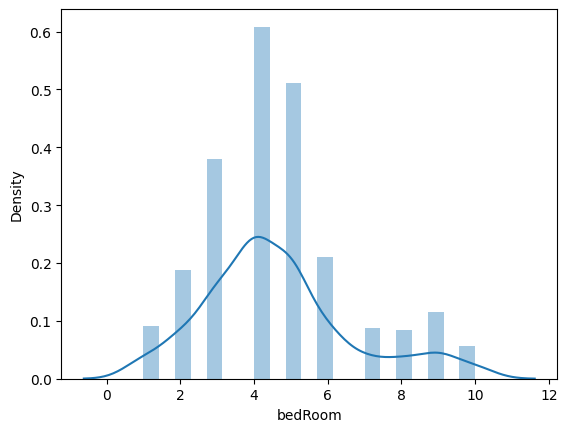

In [152]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

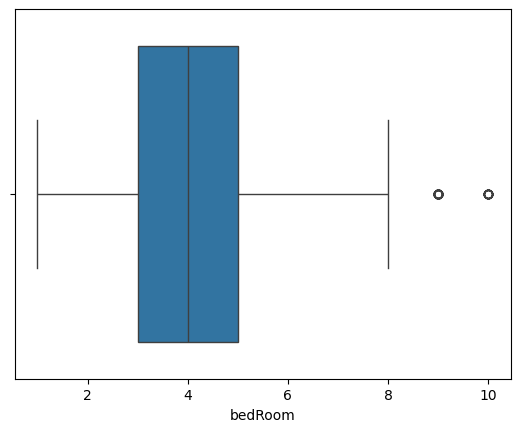

In [153]:
sns.boxplot(x=df['bedRoom'])

In [154]:
df['bedRoom'].describe()

count    744.000000
mean       4.610215
std        2.020408
min        1.000000
25%        3.000000
50%        4.000000
75%        5.000000
max       10.000000
Name: bedRoom, dtype: float64

### Bathroom

C:\Users\kael7\AppData\Local\Temp\ipykernel_44368\2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

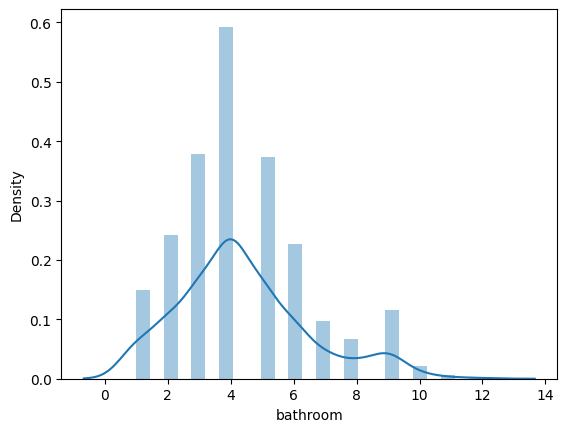

In [155]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

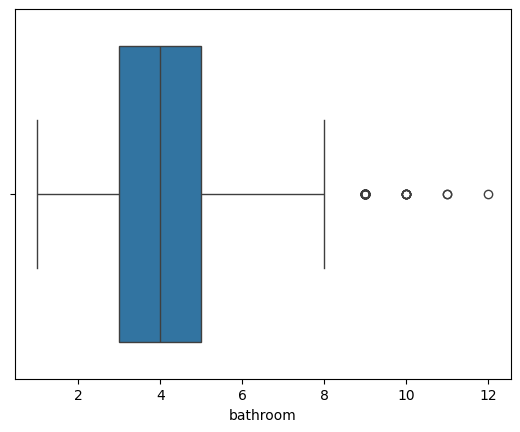

In [156]:
sns.boxplot(x=df['bathroom'])

In [157]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
161,house,adani brahma samsara,sector 60,NaN,28200.0,Built Up area: 6390 (593.65 sq.m.),9.0,12.0,3+,3.0,North-East,1 to 5 Year Old,6390.0,NaN,6390.0,NaN,0.0,1.0,0.0,0.0,0.0,1.0,146.0
201,house,NaN,sector 24,NaN,28898.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8.0,11.0,3+,3.0,East,10+ Year Old,3806.0,NaN,5000.0,NaN,1.0,1.0,0.0,1.0,1.0,1.0,39.0
211,house,NaN,sector 39,NaN,10000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10.0,11.0,3+,4.0,South-East,1 to 5 Year Old,7000.0,NaN,7000.0,NaN,0.0,0.0,0.0,1.0,0.0,2.0,38.0


In [158]:
df.head()

,property_type,society,sector,price,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
11,house,NaN,sector 12,NaN,6034.0,Plot area 1160(107.77 sq.m.),3.0,3.0,0,1.0,North-East,1 to 5 Year Old,1160.0,NaN,1160.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,23.0
14,house,NaN,sector 6,NaN,13889.0,Plot area 40(33.45 sq.m.),5.0,3.0,3,3.0,NaN,10+ Year Old,360.0,NaN,40.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21,house,NaN,sector 25,NaN,38760.0,Plot area 215(179.77 sq.m.),9.0,9.0,3,4.0,East,1 to 5 Year Old,1961.0,NaN,215.0,NaN,1.0,0.0,1.0,1.0,0.0,1.0,84.0
24,house,NaN,sector 12,NaN,14184.0,Plot area 846(78.6 sq.m.)Built Up area: 846 sq...,4.0,4.0,2,2.0,North,1 to 5 Year Old,846.0,NaN,846.0,NaN,0.0,0.0,0.0,1.0,0.0,1.0,7.0
32,house,NaN,sector 55,NaN,44444.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9.0,9.0,3+,5.0,East,0 to 1 Year Old,1125.0,NaN,115.0,100.0,0.0,0.0,0.0,0.0,1.0,1.0,44.0


### super built up area

C:\Users\kael7\AppData\Local\Temp\ipykernel_44368\4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])
c:\Users\kael7\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\distributions.py:2464: RuntimeWarning: Mean of empty slice.
  line, = ax.plot(a.mean(), 0)
c:\Users\kael7\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\kael7\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value 

<Axes: xlabel='super_built_up_area'>

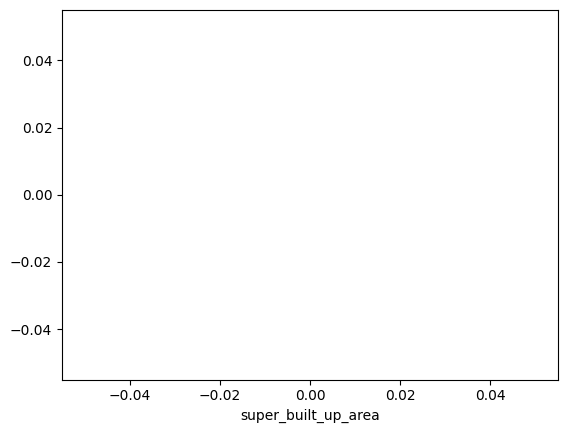

In [159]:
sns.distplot(df['super_built_up_area'])

ValueError: List of boxplot statistics and `positions` values must have same the length

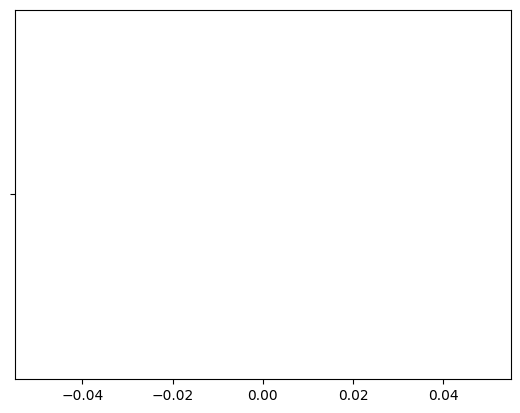

In [160]:
sns.boxplot(x=df['super_built_up_area'])

In [ ]:
df['super_built_up_area'].describe()

count     1875.000000
mean      1925.237627
std        764.172177
min         89.000000
25%       1479.500000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [ ]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1323,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4.0,4.0,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,140.0
3265,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5.0,6.0,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0.0,1.0,0.0,1.0,1.0,0.0,49.0


### built up area

C:\Users\Nitish\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='built_up_area', ylabel='Density'>

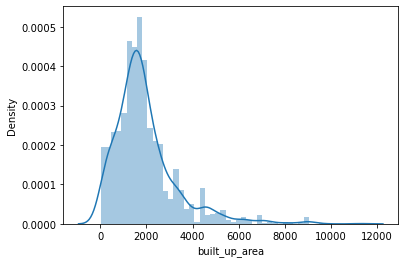

In [ ]:
sns.distplot(df['built_up_area'])

<AxesSubplot:xlabel='built_up_area'>

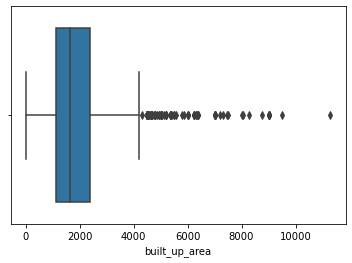

In [ ]:
sns.boxplot(x=df['built_up_area'])

In [ ]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2834,house,independent,sector 43,27.5,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6.0,7.0,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1.0,1.0,0.0,1.0,1.0,1.0,42.0


### carpet area

C:\Users\Nitish\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='carpet_area', ylabel='Density'>

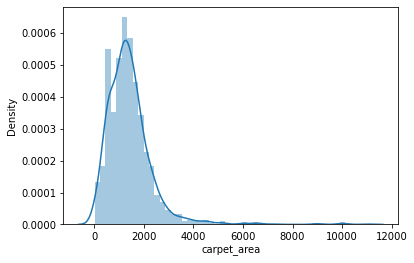

In [ ]:
sns.distplot(df['carpet_area'])

<AxesSubplot:xlabel='carpet_area'>

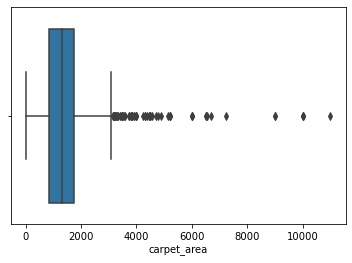

In [ ]:
sns.boxplot(x=df['carpet_area'])

In [ ]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2131,flat,godrej air,sector 85,2.5,1379.0,1812.0,Carpet area: 18122 (1683.59 sq.m.),4.0,5.0,3+,16.0,North-East,Under Construction,NaN,NaN,18122.0,1.0,0.0,0.0,1.0,1.0,1.0,44.0
2342,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4.0,4.0,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0.0,1.0,0.0,0.0,0.0,0.0,60.0


In [ ]:
df.loc[2131,'carpet_area'] = 1812

In [ ]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,15
2342,flat,m3m golfestate,sector 65,13.2,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4.0,4.0,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0.0,1.0,0.0,0.0,0.0,0.0,60.0,NaN


In [ ]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,15
0,flat,signature global park 4,sector 36,0.82,7585.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3.0,2.0,2,2.0,NaN,New Property,1081.0,NaN,650.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,NaN
1,flat,smart world gems,sector 89,0.95,8600.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2.0,2.0,2,4.0,NaN,New Property,NaN,NaN,1103.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0,NaN
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2.0,2.0,1,17.0,NaN,New Property,NaN,1000.0,585.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,NaN
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3.0,4.0,3+,10.0,North-West,Relatively New,1995.0,1615.0,1476.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0,NaN
5,flat,suncity avenue,sector 102,0.48,9022.0,532.0,Super Built up area 632(58.71 sq.m.)Carpet are...,2.0,2.0,1,5.0,North-East,Relatively New,632.0,NaN,532.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0,NaN


C:\Users\Nitish\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='luxury_score', ylabel='Density'>

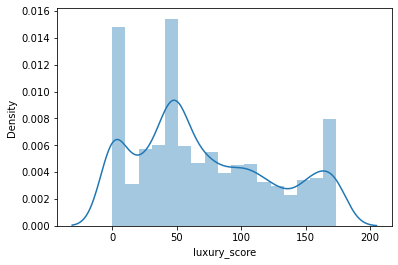

In [ ]:
sns.distplot(df['luxury_score'])

C:\Users\Nitish\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='luxury_score'>

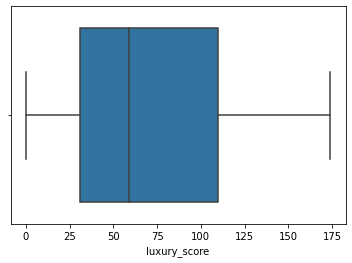

In [ ]:
sns.boxplot(df['luxury_score'])

In [ ]:
df.shape

(3588, 24)

In [ ]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

In [ ]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,15
0,flat,signature global park 4,sector 36,0.82,7586.0,1081.0,Super Built up area 1081(100.43 sq.m.)Carpet a...,3.0,2.0,2,2.0,NaN,New Property,1081.0,NaN,650.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,NaN
1,flat,smart world gems,sector 89,0.95,8597.0,1105.0,Carpet area: 1103 (102.47 sq.m.),2.0,2.0,2,4.0,NaN,New Property,NaN,NaN,1103.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0,NaN
3,flat,breez global hill view,sohna road,0.32,5470.0,585.0,Built Up area: 1000 (92.9 sq.m.)Carpet area: 5...,2.0,2.0,1,17.0,NaN,New Property,NaN,1000.0,585.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0,NaN
4,flat,bestech park view sanskruti,sector 92,1.60,8020.0,1995.0,Super Built up area 1995(185.34 sq.m.)Built Up...,3.0,4.0,3+,10.0,North-West,Relatively New,1995.0,1615.0,1476.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0,NaN
5,flat,suncity avenue,sector 102,0.48,9023.0,532.0,Super Built up area 632(58.71 sq.m.)Carpet are...,2.0,2.0,1,5.0,North-East,Relatively New,632.0,NaN,532.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0,NaN


C:\Users\Nitish\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='price_per_sqft', ylabel='Density'>

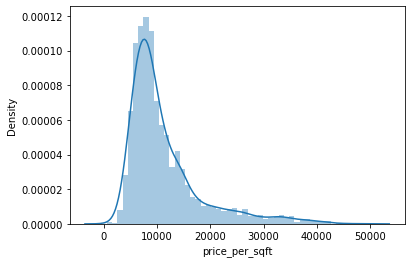

In [ ]:
sns.distplot(df['price_per_sqft'])

C:\Users\Nitish\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='price_per_sqft'>

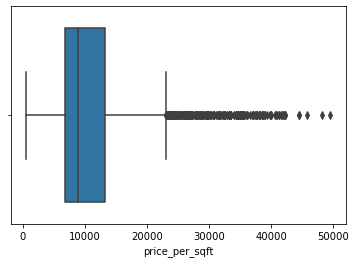

In [ ]:
sns.boxplot(df['price_per_sqft'])

In [ ]:
df[df['price_per_sqft'] > 42000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,15
711,house,independent,sector 26,20.0,44444.0,4500.0,Plot area 500(418.06 sq.m.),5.0,7.0,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0.0,1.0,0.0,1.0,0.0,2.0,97.0,NaN
901,house,independent,sector 28,12.0,42194.0,2844.0,Plot area 316(264.22 sq.m.),4.0,5.0,3+,4.0,East,Relatively New,NaN,2844.0,NaN,0.0,1.0,1.0,1.0,0.0,1.0,60.0,NaN
1090,house,independent,sector 105,9.9,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2.0,2.0,2,3.0,North,Undefined,NaN,2000.0,1800.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1509,house,independent,sector 55,5.0,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9.0,9.0,3+,5.0,East,New Property,NaN,115.0,100.0,0.0,0.0,0.0,0.0,1.0,1.0,44.0,NaN
1526,house,dlf city plots,sector 26,19.0,42054.0,4518.0,Plot area 502(419.74 sq.m.),6.0,6.0,3,2.0,East,Relatively New,NaN,4518.0,NaN,1.0,1.0,0.0,0.0,0.0,1.0,121.0,NaN
2040,house,independent,sector 43,9.5,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5.0,5.0,3+,2.0,North-East,Relatively New,NaN,300.0,250.0,0.0,1.0,0.0,1.0,0.0,1.0,88.0,NaN
2130,house,independent,sector 26,19.0,42222.0,4500.0,Plot area 500(418.06 sq.m.),6.0,8.0,3+,3.0,East,Moderately Old,NaN,4500.0,NaN,1.0,1.0,1.0,1.0,0.0,1.0,103.0,NaN
3054,house,sushant lok 1 builder floors,sector 43,13.0,48148.0,2700.0,Plot area 300(250.84 sq.m.),3.0,3.0,3+,4.0,North,New Property,NaN,2700.0,NaN,0.0,0.0,0.0,1.0,0.0,1.0,7.0,NaN
3108,house,independent,sector 25,13.0,45710.0,2844.0,Plot area 316(264.22 sq.m.),6.0,8.0,3+,NaN,NaN,Relatively New,NaN,2844.0,NaN,1.0,1.0,1.0,1.0,0.0,2.0,0.0,NaN


In [ ]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.02)

183.33333333333334

In [ ]:
df[(df['area']/df['bedRoom'])<183]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,15
37,house,independent,sector 104,0.45,12162.0,370.0,Plot area 370(34.37 sq.m.)Carpet area: 1500 sq...,4.0,4.0,2,4.0,North,Moderately Old,NaN,NaN,1500.0,0.0,0.0,0.0,0.0,0.0,1.0,7.0,NaN
48,house,ganpati heights apartment,sector 13,1.25,12077.0,1035.0,Plot area 115(7692.86 sq.m.),10.0,6.0,2,3.0,South-East,Old Property,NaN,115.0,NaN,0.0,0.0,0.0,0.0,1.0,0.0,7.0,NaN
93,house,independent,sector 105,1.10,12222.0,900.0,Carpet area: 900 (83.61 sq.m.),6.0,4.0,1,1.0,South-West,Undefined,NaN,NaN,900.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
99,house,independent,sector 4,1.10,11111.0,990.0,Built Up area: 990 (91.97 sq.m.),6.0,4.0,1,2.0,North,Undefined,NaN,990.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
186,house,independent,sector 13,1.50,11538.0,1300.0,Plot area 1300(120.77 sq.m.),10.0,7.0,3,4.0,East,Moderately Old,NaN,1300.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3686,house,independent,sector 12,0.90,13333.0,675.0,Built Up area: 675 (62.71 sq.m.),4.0,4.0,0,2.0,NaN,Undefined,NaN,675.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3713,house,independent,sector 41,4.25,26235.0,1620.0,Plot area 180(150.5 sq.m.),10.0,9.0,3+,4.0,North,Moderately Old,NaN,1620.0,NaN,1.0,1.0,0.0,0.0,0.0,1.0,36.0,NaN
3751,house,independent,sector 21,0.45,8411.0,535.0,Carpet area: 535 (49.7 sq.m.),3.0,2.0,1,1.0,NaN,Undefined,NaN,NaN,535.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3774,house,independent,sector 28,0.45,10000.0,450.0,Built Up area: 50 (4.65 sq.m.),5.0,3.0,0,1.0,NaN,Undefined,NaN,50.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
